# Classification - Example
In this script we demonstrate how a Machine Learning workflow can look like when you use a train, validation and test set. 

In [1]:
# IMPORTS - Alla bibliotek vi behöver för Machine Learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier  # NY: Random Forest

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# MACHINE LEARNING FLÖDE - Steg för steg

## **Mönstret vi följer:**
1. **Data Loading**  Ladda och utforska data
2. **Train/Val/Test Split**  Dela data i träning, validering och test
3. **EDA (Exploratory Data Analysis)**  Utforska träningsdata
4. **Model Training**  Träna flera modeller
5. **Hyperparameter Tuning**  Optimera modellparametrar
6. **Model Comparison**  Jämför modellernas prestanda
7. **Final Evaluation**  Slutlig utvärdering på testdata

---

# Loading Data

In [2]:
# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()

In [3]:
# print(iris.DESCR)

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Storing/Loading the data in the way it will be used

In [5]:
X, y = load_iris(return_X_y=True, as_frame=True)

# Only choose two variables for my model
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [6]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB
None


In [7]:
print(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


# Train, Validation, and Test Set

In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

# EDA
We are only allowed to explore / learn things on the training data when creating our model. 

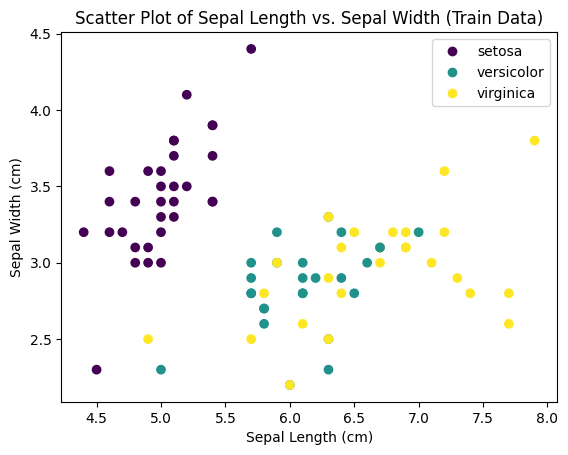

In [9]:
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

In [10]:
X_train.head()

,sepal length (cm),sepal width (cm)
72,6.3,2.5
62,6.0,2.2
74,6.4,2.9
19,5.1,3.8
93,5.0,2.3


In [11]:
y_train.head()

72    1
62    1
74    1
19    0
93    1
Name: target, dtype: int64

In [12]:
# 0 = 'setosa', 1 = 'versicolor', 2 = 'virginica'
y_train.value_counts()

target
0    32
1    26
2    26
Name: count, dtype: int64

# Training 2 different models

In [13]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [14]:
# DECISION TREE med Hyperparameter Optimization
tree_clf = DecisionTreeClassifier()

# GRIDSEARCHCV - Hitta bästa hyperparametrar
# GridSearchCV testar ALLA kombinationer av parametrar och väljer den bästa
hyper_params_tree = {'max_depth':(None, 1, 2, 5, 10)}  # Testa olika träddjup
clf = GridSearchCV(tree_clf, hyper_params_tree, cv=5, scoring='accuracy')  # 5-fold cross validation

# Träna modellen med alla parameterkombinationer
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [ ]:
# GRIDSEARCHCV RESULTAT - Förklaring av vad som händer

# clf.best_params_ - Visa de BÄSTA hyperparametrarna
print("Bästa hyperparametrar:", clf.best_params_)
print("Bästa cross-validation score:", clf.best_score_)

# clf.cv_results_ - Visa ALLA resultat från GridSearchCV
print("\nDetaljerade resultat för alla parameterkombinationer:")
cv_results_df = pd.DataFrame(clf.cv_results_)
print(cv_results_df[['param_max_depth', 'mean_test_score', 'std_test_score', 'rank_test_score']])

# FÖRKLARING:
# - param_max_depth: Vilka max_depth värden som testades
# - mean_test_score: Genomsnittlig accuracy för varje parameter
# - std_test_score: Standardavvikelse (hur stabilt resultatet är)
# - rank_test_score: Rankning (1 = bästa resultatet)

 Bästa hyperparametrar: {'max_depth': 2}
 Bästa cross-validation score: 0.7485294117647059

 Detaljerade resultat för alla parameterkombinationer:
  param_max_depth  mean_test_score  std_test_score  rank_test_score
0            None         0.677941        0.073294                3
1               1         0.653676        0.052634                5
2               2         0.748529        0.099349                1
3               5         0.712500        0.101471                2
4              10         0.666176        0.089646                4


In [ ]:
# RANDOM FOREST med Hyperparameter Optimization
rf_clf = RandomForestClassifier(random_state=42)

# GRIDSEARCHCV för Random Forest - Testa flera hyperparametrar
hyper_params_rf = {
    'n_estimators': [50, 100, 200],      # Antal träd i skogen
    'max_depth': [None, 5, 10, 15],      # Max djup för varje träd
    'min_samples_split': [2, 5, 10]      # Minsta antal samples för att dela en nod
}

# GridSearchCV med Random Forest
rf_grid = GridSearchCV(rf_clf, hyper_params_rf, cv=5, scoring='accuracy', n_jobs=-1)

# Träna Random Forest med alla parameterkombinationer
rf_grid.fit(X_train, y_train)
rf_pred = rf_grid.predict(X_val)

print("Random Forest tränad!")


 Random Forest tränad!


In [ ]:
# RANDOM FOREST RESULTAT
print("Random Forest - Bästa hyperparametrar:", rf_grid.best_params_)
print("Random Forest - Bästa cross-validation score:", rf_grid.best_score_)

# Visa de bästa resultaten
print("\nRandom Forest - Top 5 parameterkombinationer:")
rf_results_df = pd.DataFrame(rf_grid.cv_results_)
top_5_rf = rf_results_df.nlargest(5, 'mean_test_score')[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'rank_test_score']]
print(top_5_rf)


 Random Forest - Bästa hyperparametrar: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}
 Random Forest - Bästa cross-validation score: 0.7257352941176471

 Random Forest - Top 5 parameterkombinationer:
    param_n_estimators param_max_depth  param_min_samples_split  \
15                  50               5                       10   
7                  100            None                       10   
17                 200               5                       10   
25                 100              10                       10   
34                 100              15                       10   

    mean_test_score  rank_test_score  
15         0.725735                1  
7          0.713971                2  
17         0.713971                2  
25         0.713971                2  
34         0.713971                2  


## Choosing the best model through validation set

c:\Users\daedi\.vscode\Categories\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


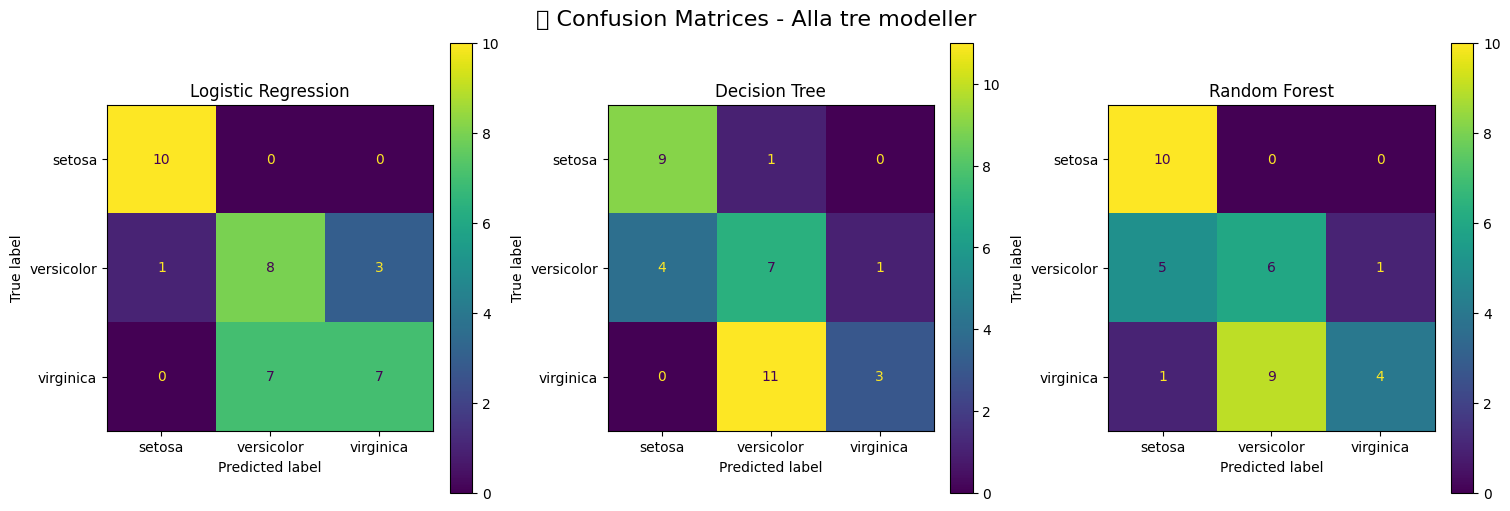

In [ ]:
# MODELLJÄMFÖRELSE - Alla tre modeller
target_names_iris = ['setosa', 'versicolor', 'virginica']

# Skapa confusion matrices för alla tre modeller
cm1 = confusion_matrix(y_val, log_reg_pred)      # Logistic Regression
cm2 = confusion_matrix(y_val, clf_pred)          # Decision Tree
cm3 = confusion_matrix(y_val, rf_pred)           # Random Forest

# Visa alla tre confusion matrices
fig, axs = plt.subplots(1, 3, figsize = (15, 5), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = target_names_iris).plot(ax=axs[0])
axs[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(cm2, display_labels = target_names_iris).plot(ax=axs[1])
axs[1].set_title('Decision Tree')

ConfusionMatrixDisplay(cm3, display_labels = target_names_iris).plot(ax=axs[2])
axs[2].set_title('Random Forest')

plt.suptitle('Confusion Matrices - Alla tre modeller', fontsize=16)
plt.show()

In [ ]:
# KLASSIFICERINGSrapporter för alla tre modeller

print("LOGISTIC REGRESSION:")
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))

print("\nDECISION TREE:")
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

print("\nRANDOM FOREST:")
print(classification_report(y_val, rf_pred, target_names=target_names_iris))


 LOGISTIC REGRESSION:
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36


 DECISION TREE:
              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36


 RANDOM FOREST:
              precision    recall  f1-score   support

      setosa       0.62      1.00      0.77        10
  versicolor       0.40      0.50      0.44        12
   virginica       

In [ ]:
# MODELLJÄMFÖRELSE - Sammanfattning

# Beräkna accuracy för alla modeller
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_val, log_reg_pred)
dt_accuracy = accuracy_score(y_val, clf_pred)
rf_accuracy = accuracy_score(y_val, rf_pred)

print("ACCURACY JÄMFÖRELSE:")
print(f"Logistic Regression: {lr_accuracy:.3f}")
print(f"Decision Tree:       {dt_accuracy:.3f}")
print(f"Random Forest:       {rf_accuracy:.3f}")

# Hitta bästa modellen
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_accuracy, dt_accuracy, rf_accuracy]
best_model_idx = np.argmax(accuracies)

print(f"\nBÄSTA MODELL: {models[best_model_idx]} med accuracy {accuracies[best_model_idx]:.3f}")

# Visa cross-validation scores
print(f"\nCROSS-VALIDATION SCORES:")
print(f"Decision Tree:       {clf.best_score_:.3f}")
print(f"Random Forest:       {rf_grid.best_score_:.3f}")
print("Logistic Regression: Ingen CV (ingen hyperparameter tuning)")


 ACCURACY JÄMFÖRELSE:
Logistic Regression: 0.694
Decision Tree:       0.528
Random Forest:       0.556

 BÄSTA MODELL: Logistic Regression med accuracy 0.694

 CROSS-VALIDATION SCORES:
Decision Tree:       0.749
Random Forest:       0.726
Logistic Regression: Ingen CV (ingen hyperparameter tuning)


In [21]:
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36



### Analysis of Decision Tree Results

**Setosa (Class 0):**
- Precision: 0.69 - When the model predicts setosa, it's correct 69% of the time
- Recall: 0.90 - The model found 90% of actual setosa flowers (9/10)
- F1-Score: 0.78 - Good balance, but some false positives

**Versicolor (Class 1):**
- Precision: 0.37 - When the model predicts versicolor, it's only correct 37% of the time
- Recall: 0.58 - The model found 58% of actual versicolor flowers (7/12)
- F1-Score: 0.45 - Poor performance, many false positives

**Virginica (Class 2):**
- Precision: 0.75 - When the model predicts virginica, it's correct 75% of the time
- Recall: 0.21 - The model only found 21% of actual virginica flowers (3/14)
- F1-Score: 0.33 - Poor performance, missing most virginica instances

**Overall Performance:**
- Accuracy: 53% - The model is correct only 53% of the time overall
- Macro Average: 0.60 - Average performance across all classes
- Weighted Average: 0.61 - Performance weighted by class size

**Conclusion:** The Decision Tree performs worse than Logistic Regression, especially for virginica classification.


In [22]:
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



# Evaluating chosen model through test set

The results are extremely good since this is a "toy dataset". In reality we do not expect numbers that are as perfect as those below. 

In [23]:
# Now we retrain our model on the train + validation data. 
log_reg_final = LogisticRegression().fit(X_train_full, y_train_full)
pred_test = log_reg_final.predict(X_test)

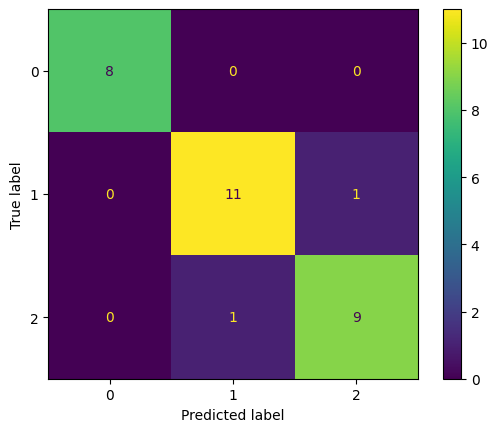

In [24]:
cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test).plot()

In [25]:
print(classification_report(y_test, pred_test, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30

